In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal

plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = "both"
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.size'] = 8

In [2]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../llrf_dsp/tests')
from llrf_dsp import DDC

# RAW ADC data demodulation numerical simulation

In [14]:
amp, phs = 8000, 20  # cnt, deg
noise_amp = 10
length = 4096
dc_off = 25

omega = 2 * np.pi * 3 / 14
sim_adc = amp * np.cos(omega * np.arange(length) - np.deg2rad(phs))
noise = np.random.randn(length) - 0.5
sim_adc += noise * noise_amp
sim_adc += dc_off

In [15]:
ddc = DDC(num=3, den=14)
ddc_data = ddc.calc_ddc_raw(sim_adc)

In [16]:
amp_mean = np.abs(ddc_data).mean()
amp_std = np.abs(ddc_data).std()
phs_mean = np.angle(ddc_data, deg=True).mean()
phs_std = np.angle(ddc_data, deg=True).std()
print(f'Measured amplitude: {amp_mean:8.3f}, rms {amp_std:8.3f}; expect {amp:8.3f} cnt')
print(f'Measured phase    : {phs_mean:8.3f}, rms {phs_std:8.3f}; expect {phs:8.3f} deg')

Measured amplitude: 8000.432, rms   20.953; expect 8000.000 cnt
Measured phase    :   20.001, rms    0.148; expect   20.000 deg


## Test pulsing / step response

In [17]:
def plot_rf_time(wfm, title='', fs_mhz=119):
    t = np.arange(wfm.shape[-1]) / fs_mhz
    fig, axes = plt.subplots(2, sharex=True)
    amp, phs = np.abs(wfm), np.angle(wfm, deg=True)
    axes[-1].set_xlabel('Time [us]')
    axes[0].set_ylabel('Amplitude [cnt]')
    axes[1].set_ylabel('Phase [deg]')
    axes[0].plot(t, amp)
    axes[1].plot(t, phs)

In [18]:
sim_adc[:100] = 0
sim_adc[300:] = 0

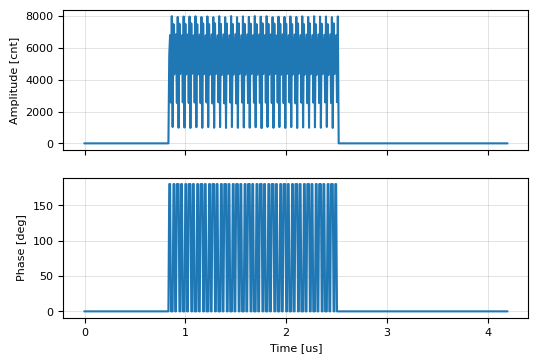

In [19]:
plot_rf_time(sim_adc[:500])

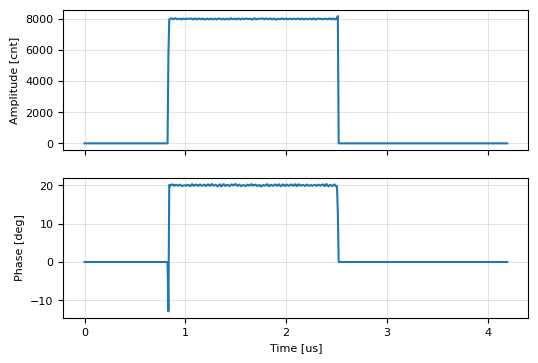

In [20]:
ddc_data = ddc.calc_ddc_raw(sim_adc)
plot_rf_time(ddc_data[:500])

## Effects in harmonics in raw ADC waveforms

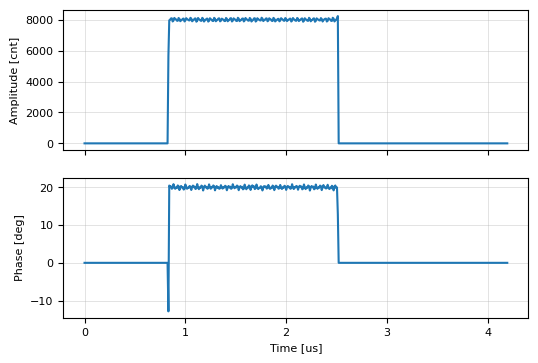

In [21]:
sim_adc += 0.01 * amp * np.cos(2 * omega * np.arange(length))
sim_adc[:100] = 0
sim_adc[300:] = 0
ddc_data = ddc.calc_ddc_raw(sim_adc)
plot_rf_time(ddc_data[:500])